In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from scipy.optimize import curve_fit
from scipy.optimize import minimize
from scipy.special import lambertw

In [2]:
# Define the phase boundary model
def model(x, s, b, c, p):
    return s * x**(-b) * np.exp(c * x * np.exp(-p * x))

  
def panel_label_outside(ax, text, x=-0.28, y=1.12, fontsize=11, bold=False):
    ax.text(
        x, y, f"({text})" if len(text) == 1 else text,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=fontsize,
        fontweight="bold" if bold else "normal",
        clip_on=False
    )



/var/folders/w9/n4kr9ydx5fb4kz8n6dd4z2zw0000gn/T/ipykernel_9290/664241231.py:3: RuntimeWarning: divide by zero encountered in reciprocal
  return s * x**(-b) * np.exp(c * x * np.exp(-p * x))


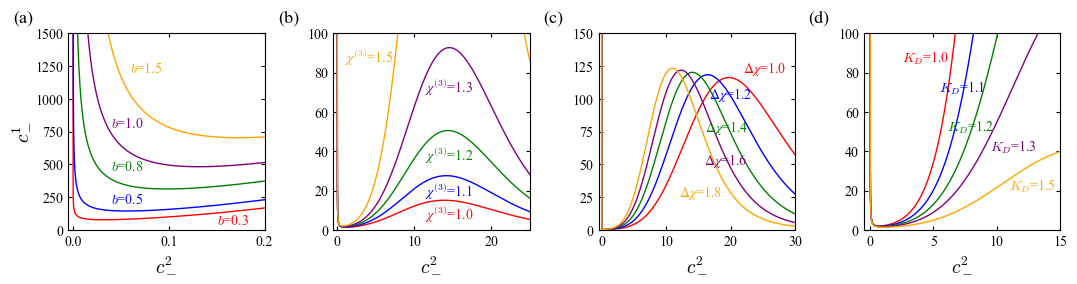

In [3]:
# Plot Figure 2
# Phase boundary geometry controlled by the physical parameters
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "cm",
    "font.size": 10,
    "axes.linewidth": 0.8,
    "axes.labelsize": 14,
    "axes.titlesize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 1.5,
    "ytick.minor.size": 1.5,
    "legend.frameon": False,
    "errorbar.capsize": 2.5,
})


fig, axes = plt.subplots(1, 4, figsize=(12.8, 3.0) )

plt.subplots_adjust(wspace=0.35)

for ax in axes:
    ax.set_box_aspect(1) 
    ax.tick_params(which='both', top=True, right=True)
    
# Colors
colors = ['red', 'blue', 'green', 'purple', 'orange']


# -------------------------------------------------------------------------
# (a) Reentrant Phase Boundary vs phase separation parameter b
# -------------------------------------------------------------------------
x = np.linspace(1e-25, 0.5, 5000)
b_values = [0.3, 0.5, 0.8, 1.0, 1.2]
for i, (b, color) in enumerate(zip(b_values, colors)):
    axes[0].plot(x, model(x, 20, b, 10, 1.0), color=color, lw=1)
axes[0].text(0.150, 40,  r'$b$=0.3',  color='red')
axes[0].text(0.040, 200, r'$b$=0.5',  color='blue')
axes[0].text(0.040, 450, r'$b$=0.8', color='green')
axes[0].text(0.040, 780, r'$b$=1.0', color='purple')
axes[0].text(0.060, 1200, r'$b$=1.5', color='orange')
axes[0].set_xlabel('$c^2_-$')
axes[0].set_ylabel('$c^1_-$')
axes[0].set_xlim(-0.005, 0.2)
axes[0].set_ylim(0, 1500)
panel_label_outside(axes[0], "a", fontsize = 13)



# -------------------------------------------------------------------------
# (b) Reentrant Phase Boundary vs three-body repulsion χ^(3)
# -------------------------------------------------------------------------
x = np.linspace(0, 25, 8000)
c_values = [1.0, 1.1, 1.2, 1.3, 1.5]
for c, color in zip(c_values, colors):
    axes[1].plot(x, model(x, 0.5, 1.0, c, 0.06), color=color, lw=1)  # three-body repulsion controls c
axes[1].text(11.4, 5,  r'$χ^{(3)}$=1.0',  color='red')
axes[1].text(11.4, 17, r'$χ^{(3)}$=1.1',  color='blue')
axes[1].text(11.4, 35, r'$χ^{(3)}$=1.2', color='green')
axes[1].text(11.4, 70, r'$χ^{(3)}$=1.3', color='purple')
axes[1].text(1, 85, r'$χ^{(3)}$=1.5', color='orange')
axes[1].set_xlabel('$c^2_-$')
axes[1].set_xlim(-0.5, 25)
axes[1].set_ylim(0, 100)
panel_label_outside(axes[1], "b", fontsize = 13)


# -------------------------------------------------------------------------
# Fig. 2(c) Reentrant Phase Boundary vs competition Δχ
# -------------------------------------------------------------------------
x1 = np.linspace(1e-50, 1e-10, 10000)
x2 = np.linspace(1e-10, 30, 2000)
x = np.concatenate((x1, x2))

c_values = np.array([1.0, 1.2, 1.4, 1.6, 1.8])
p_values = 0.05 * c_values

for c, p, color in zip(c_values, p_values, colors):
    axes[2].plot(x, model(x, 0.1, 0.1, c, p), color=color, lw=1)   # competition enters both c and p
axes[2].text(22, 120, r'$Δχ$=1.0', color='red')
axes[2].text(16.6, 100, r'$Δχ$=1.2', color='blue')
axes[2].text(16.1, 75, r'$Δχ$=1.4', color='green')
axes[2].text(15.8, 50, r'$Δχ$=1.6', color='purple')
axes[2].text(12, 25, r'$Δχ$=1.8', color='orange')
axes[2].set_xlabel('$c^2_-$')
axes[2].set_xlim(-0.5, 30)
axes[2].set_ylim(0.0, 150)
panel_label_outside(axes[2], "c", fontsize = 13)


# -------------------------------------------------------------------------
# (d) Reentrant Phase Boundary vs Dissociaiton constant K_D 
# -------------------------------------------------------------------------
x1 = np.linspace(1e-50, 1e-10, 10000)
x2 = np.linspace(1e-10, 30, 2000)
x = np.concatenate((x1, x2))

k_values = np.array([1.0, 1.1, 1.2, 1.3, 1.5])
c_values = 1.5 / k_values
for c, color in zip(c_values, colors):
    axes[3].plot(x, model(x, 0.5, 1.0, c, 0.05), color=color, lw=1)
axes[3].text(2.5, 85,  r'$K_D$=1.0',  color='red')
axes[3].text(5.4, 70, r'$K_D$=1.1',  color='blue')
axes[3].text(6.1, 50, r'$K_D$=1.2', color='green')
axes[3].text(9.5, 40, r'$K_D$=1.3', color='purple')
axes[3].text(11, 20, r'$K_D$=1.5', color='orange')
axes[3].set_xlabel('$c^2_-$')
axes[3].set_xlim(-0.5, 15)
axes[3].set_ylim(0, 100)
panel_label_outside(axes[3], "d", fontsize = 13)



# ==============================================================
# Export
# ==============================================================
#fig.savefig("Figure_2.pdf", bbox_inches="tight")
#fig.savefig("Figure_2.png", dpi=600)

plt.show()